# Test Decoder: Rotated Surface Code Memory Experiment

Memory experiment of rotated surface code with pymatching decoder.
LER vs PER (Physical Error Rate) for distances d = 3, 5, 7.

In [6]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.memory import MemoryExperiment
from src.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from src.qec_code.surface_code.toric import ToricCode, ToricCodeExtractionBlock
from src.ir.qec_system import QECSystem
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig
from src.plot import plot_ler_vs_p

In [7]:
# Parameters: short PER list and low max_errors for fast simulation
DISTANCES = [3, 5, 7]
PER_LIST = [1e-3, 2e-3, 5e-3, 1e-2]
MAX_ERRORS = 25
NUM_WORKERS = 1  # Single-thread for notebooks (multiprocessing can be tricky)

In [8]:
# Build tasks: for each (d, p) create a stim circuit and metadata
tasks = []
for d in DISTANCES:
    for p in PER_LIST:
        # Create rotated surface code and system
        surface_code = RotatedSurfaceCode(distance = d) # Rotated Surface Code
        system = QECSystem()
        system.add_patch(surface_code, name="rotated")
        
        # Noise params with uniform p for all error types
        noise_params = NoiseConfig(
            p_idle=p, p_meas=p, p_reset=p,
            p_1q=p, p_2q=p
        )
        
        # Build memory experiment circuit (suppress print)
        import io
        import contextlib
        with contextlib.redirect_stdout(io.StringIO()):
            mem_exp = MemoryExperiment(
                qec_system=system,
                extraction_block_class=RotatedSurfaceCodeExtractionBlock,
                rounds=d,
                noise_params=noise_params,
                noise_model='circuit_level',
                basis='Z',
            )
            circuit = mem_exp.build()
        
        tasks.append(ExperimentTask(circuit, json_metadata={"d": d, "p": p}))

print(f"Built {len(tasks)} tasks")

Built 12 tasks


In [9]:
# Run simulation with pymatching decoder
decoder_config = DecoderConfig("pymatching", backend="cpu")
pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=MAX_ERRORS,
    max_shots=1_000_000,
    num_workers=NUM_WORKERS,
    print_progress=True,
)

df = pipeline.run_batch(tasks)
df

Starting 1 workers...


Task 1/12: {'d': 3, 'p': 0.001}


1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
        1 pymatching   ?     958767           0 d=3,p=0.001  
Starting 1 workers...


Task 2/12: {'d': 3, 'p': 0.002}


1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        1 pymatching [draining]     989487          -3 d=3,p=0.002  
Starting 1 workers...


...

Task 11/12: {'d': 7, 'p': 0.005}


1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
        1 pymatching <1m     998703          14 d=7,p=0.005  
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        1 pymatching [draining]     996655          -3 d=7,p=0.005  
Starting 1 workers...


Task 12/12: {'d': 7, 'p': 0.01}


1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        1 pymatching [draining]     999727          -9 d=7,p=0.01   


,shots,post_selected_shots,post_selection_rate,errors,logical_error_rate,seconds,decoder,d,p
0,41233,41233,1.0,25,0.000606,0.006213,pymatching,3,0.001
1,10513,10513,1.0,28,0.002663,0.002274,pymatching,3,0.002
2,2321,2321,1.0,40,0.017234,0.001236,pymatching,3,0.005
3,1297,1297,1.0,64,0.049345,0.001510,pymatching,3,0.010
4,223505,223505,1.0,25,0.000112,0.138688,pymatching,5,0.001
5,25873,25873,1.0,27,0.001044,0.028164,pymatching,5,0.002
6,1297,1297,1.0,25,0.019275,0.004602,pymatching,5,0.005
7,1297,1297,1.0,103,0.079414,0.008628,pymatching,5,0.010
8,1000000,1000000,1.0,14,0.000014,1.886137,pymatching,7,0.001
9,115985,115985,1.0,26,0.000224,0.384223,pymatching,7,0.002


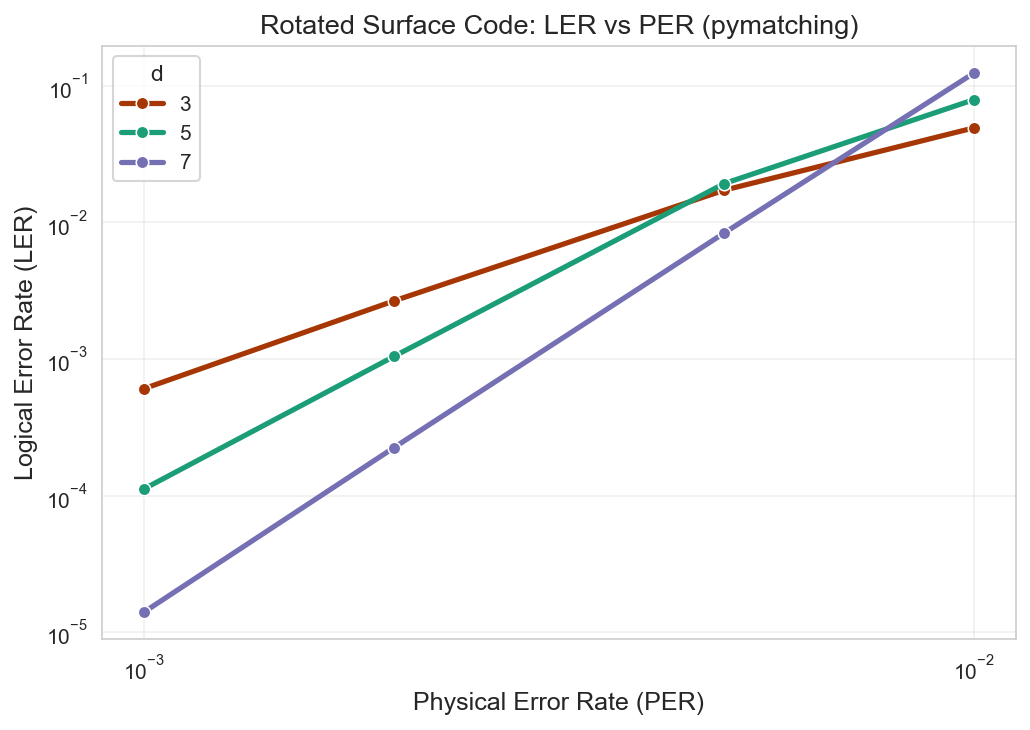

In [12]:
# Plot LER vs PER using our plot module
# Trailing ; suppresses duplicate display (plt.show already shows; Jupyter also displays returned fig)
plot_ler_vs_p(
    df,
    hue="d",
    x_col="p",
    x_label="Physical Error Rate (PER)",
    y_label="Logical Error Rate (LER)",
    title="Rotated Surface Code: LER vs PER (pymatching)"
);